In [1]:
import radiate as rd
import polars as pl
from IPython.display import display, HTML


# import polars as pl  # type: ignore
import matplotlib.pyplot as plt  # type: ignore

rd.random.seed(67123)

In [2]:
class ScorePlotterHandler(rd.EventHandler):
    def __init__(self):
        super().__init__()
        self.scores = []

    def on_event(self, event: rd.EngineEvent) -> None:
        if event.event_type() == rd.EventType.EPOCH_COMPLETE:
            best_score = event.score()
            self.scores.append(best_score)
        elif event.event_type() == rd.EventType.STOP:
            plt.plot(list(range(len(self.scores))), self.scores)
            # plt.xlabel("Generation")
            # plt.ylabel("Best Score")
            # plt.title("Best Score over Generations")
            plt.grid(True)
            plt.show()


def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])

PyEngineInput { 
	component: TournamentSelector, 
	input_type: OffspringSelector, 
	allowed_genes: {Char, Permutation, Int, Bit, GraphNode, TreeNode, Float}, 
	rate: None, 
	args: {
		k: PyAnyObject { inner: Py(0x1068ef7c0) }
} 
}
PyEngineInput { 
	component: RouletteSelector, 
	input_type: SurvivorSelector, 
	allowed_genes: {TreeNode, Float, Permutation, GraphNode, Char, Int, Bit}, 
	rate: None, 
	args: {} 
}
PyEngineInput { 
	component: PopulationSize, 
	input_type: PopulationSize, 
	allowed_genes: {GraphNode, Float, Int, Bit, TreeNode, Permutation, Char}, 
	rate: None, 
	args: {
		size: PyAnyObject { inner: Py(0x1068f03e0) }
} 
}
PyEngineInput { 
	component: OffspringFraction, 
	input_type: OffspringFraction, 
	allowed_genes: {Float, GraphNode, Bit, Int, Char, TreeNode, Permutation}, 
	rate: None, 
	args: {
		fraction: PyAnyObject { inner: Py(0x10c55dbf0) }
} 
}
PyEngineInput { 
	component: MaxPhenotypeAge, 
	input_type: MaxPhenotypeAge, 
	allowed_genes: {Bit, Int, Float, Char, Tree

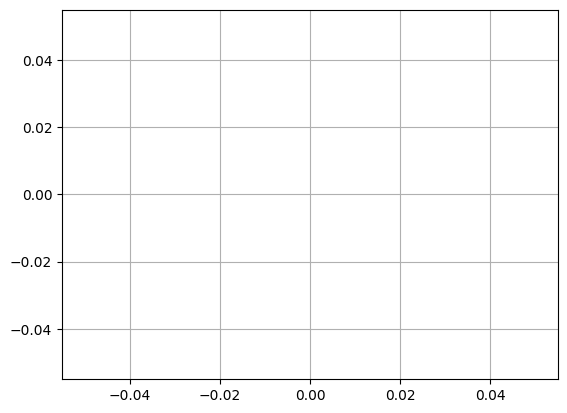

ValueError: At least one limit must be provided

In [3]:
subscriber = ScorePlotterHandler()
collector = rd.MetricCollector()

limit = rd.Limit.expr(rd.metric("scores").rolling(10).mean() < 0.1)

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(subscriber, collector)
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(limit)
    # .limit(rd.Limit.generations(1000), rd.Limit.score(0.001))
)

result = engine.run(log=True)

In [ ]:
eval_results = result.value().eval(inputs)
accuracy = rd.accuracy(result.value(), inputs, answers, loss=rd.MSE)

print(result)
print(result.metrics().dashboard())
print(accuracy)


(
	index=602,
	score=[0.0008283],
	dtype=Struct({'GraphNode': Struct({'op': Float32})}),
	MetricSet[metrics=39, updates=118083],
	value=Graph(
[0  ] [113228 ] "Inp" :: Zero  Var: X0(0)   V:true  R:false 0  6  < []
[1  ] [113230 ] "Out" :: Any   Fn: linear   V:true  R:false 7  0  < [0, 2, 3, 4, 7, 13, 15]
[2  ] [111732 ] "Ver" :: Any   Fn: linear   V:true  R:false 1  3  < [0]
[3  ] [113233 ] "Ver" :: Any   Fn: linear   V:true  R:false 1  1  < [2]
[4  ] [112330 ] "Ver" :: 2     Fn: mul      V:true  R:false 2  4  < [0, 2]
[5  ] [113236 ] "Edg" :: 1     Val: w(1.4067532) V:true  R:false 1  1  < [10]
[6  ] [113238 ] "Edg" :: 1     Val: w(0.6492858) V:true  R:false 1  1  < [4]
[7  ] [114237 ] "Edg" :: 1     Val: w(-1.1796885) V:true  R:false 1  1  < [8]
[8  ] [114563 ] "Edg" :: 1     Val: w(1.1484739) V:true  R:false 1  1  < [5]
[9  ] [115491 ] "Ver" :: Any   Fn: linear   V:true  R:false 1  1  < [6]
[10 ] [115706 ] "Ver" :: Any   Fn: linear   V:true  R:false 4  1  < [9, 12, 14, 20]
[11 ] [11

In [ ]:
df = collector.to_polars(lazy=False)
df


name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,version,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""diversity_ratio""",0.57,0.57,0.57,0.0,0.0,NaN,0.57,0.57,1,null,null,null,null,null,null,1,1,"[""derived"", ""statistic""]"
"""unique_members""",57.0,57.0,57.0,0.0,0.0,NaN,57.0,57.0,1,null,null,null,null,null,null,1,1,"[""derived"", ""statistic""]"
"""filter_step""",0.0,null,null,null,null,null,null,null,1,2µs,2µs,0µs,2µs,2µs,0µs,1,1,"[""time"", ""step""]"
"""lineage_parents_ratio""",0.08,0.08,0.08,0.0,0.0,NaN,0.08,0.08,1,null,null,null,null,null,null,1,1,"[""age"", ""statistic"", ""lineage""]"
"""op_mutate""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,80,null,null,null,null,null,null,1,80,"[""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""recombine_step""",0.0,null,null,null,null,null,null,null,602,43495µs,72µs,13µs,46µs,142µs,0µs,602,1,"[""time"", ""step""]"
"""evaluate_step""",0.0,null,null,null,null,null,null,null,1204,45860µs,38µs,48µs,0µs,221µs,0µs,602,2,"[""time"", ""step""]"
"""replace_age""",19.0,378.0,9.692307,9.43441,89.008102,1.64885,1.0,41.0,39,null,null,null,null,null,null,532,1,"[""failure"", ""age"", ""statistic""]"


In [ ]:
filtered = (
    df.filter(pl.col("name") == "best_score_improvement")
    .select("version")
    .unique()
    .sort("version")
)
filtered

version
i64
3
373
375
377
378
…
596
597
598


In [ ]:
display(HTML(filtered._repr_html_()))

version
i64
3
373
375
377
378
…
596
597
598
